# Notebook 02 — Extracción de Características

**Proyecto:** Clasificación de ensayos EEG (match vs mismatch) — Track A · ML Clásico
**Autores:** Jose Pablo Agüero Mora, Roilin Navarro Vargas

## ¿Qué hace este notebook?

Cada epoch EEG es una matriz de **2 canales × 257 muestras temporales** (514 números crudos). Los modelos de ML clásico funcionan mejor sobre **resúmenes interpretables** de esa señal, no sobre la señal en bruto. Este notebook convierte cada epoch en un **vector de ~55 características numéricas** que capturan información relevante para la clasificación.

## Familias de características extraídas

### 1. Temporales (dominio del tiempo)

Calculadas en dos ventanas: la **ventana N400 (250–600 ms)** y la **epoch completa**.

Por canal y por ventana:
- **Amplitud media** (`mean`) — la feature ERP clásica.
- **Desviación estándar** (`std`) y varianza (`var`) — variabilidad.
- **Raíz cuadrática media** (`RMS`) — energía promedio.
- **Peak-to-peak** — rango dinámico.
- **Asimetría** (`skewness`) — desviación de la simetría gaussiana.
- **Curtosis** — apuntamiento de la distribución.
- **Área bajo la curva** — integral temporal de la amplitud.
- **Pendiente** (`slope`) — tendencia lineal en la ventana.

### 2. Frecuenciales (dominio de las frecuencias)

Mediante **estimación espectral de potencia por el método de Welch**, calculamos la potencia integrada en bandas canónicas:
- **Delta** (1–4 Hz) — actividad lenta.
- **Theta** (4–8 Hz) — asociada a procesamiento cognitivo.
- **Alpha** (8–13 Hz) — actividad de reposo.
- **Beta** (13–30 Hz) — actividad cortical activa.

Más ratios espectrales (`theta/alpha`, `beta/alpha`) que cuantifican balance entre bandas.

### 3. Inter-canal

- **Asimetría frontal** (AF7 − AF8) en amplitud media N400.
- **Diferencias en potencias** por banda entre los dos canales.

## Salidas

- `features/02_features_matrix.csv` — matriz tabular `n_epochs × n_features` con `subject_id` y `label` como columnas auxiliares.
- `reports/02_feature_dictionary.json` — definición operativa de cada feature.
- `figures/02_*` — visualizaciones del dataset tabular (distribuciones, correlaciones, sanity check).

## Resiliencia

Si el CSV de salida ya existe y `FORCE_RERUN=False`, se carga sin reprocesar.

## 1. Setup

In [1]:
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'
FORCE_RERUN = False

print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')
print(f'FORCE_RERUN:        {FORCE_RERUN}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400
FORCE_RERUN:        False


## 2. Instalación de dependencias

Versiones modernas, compatibles con NumPy 2.x. Después de instalar, hay un reinicio forzado del kernel.

In [2]:
%%capture
!pip install -q --upgrade --no-cache-dir "shap>=0.46.0"
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

### Reinicio forzado del kernel

Esta celda mata el proceso para que Python recargue limpio. Tras el reinicio:
1. **No** correr la celda de instalación de nuevo (los paquetes quedan).
2. Empezar a ejecutar desde la celda 1 (PROJECT_ROOT_DRIVE).
3. **Saltarse** esta celda de `os.kill` en el segundo pase.

In [ ]:
# Solo ejecutar la PRIMERA vez. En el segundo pase, saltarla.
import os
os.kill(os.getpid(), 9)

## 3. Imports

In [3]:
import os
import sys
import json
import yaml
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from scipy import stats, signal
import mne
mne.set_log_level('WARNING')

print(f'Python: {sys.version.split()[0]}')
print(f'NumPy:  {np.__version__}')
print(f'SciPy:  {__import__("scipy").__version__}')
print(f'MNE:    {mne.__version__}')

Python: 3.12.13
NumPy:  2.0.2
SciPy:  1.16.3
MNE:    1.12.1


## 4. Drive + configuración

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

assert os.path.exists(PROJECT_ROOT_DRIVE), f'No existe: {PROJECT_ROOT_DRIVE}'

CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'
with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
FEATURES_DIR = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir']
EPOCHS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['epochs_dir']

print(f'✓ Config cargada')
print(f'✓ EPOCHS_DIR:   {EPOCHS_DIR}')
print(f'✓ FEATURES_DIR: {FEATURES_DIR}')

Mounted at /content/drive
✓ Config cargada
✓ EPOCHS_DIR:   /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/features/epochs_clean
✓ FEATURES_DIR: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/features


## 5. Verificar que el Notebook 01 corrió

In [5]:
fif_files = sorted(EPOCHS_DIR.glob('*-epo.fif'))
assert len(fif_files) > 0, 'No hay archivos .fif. Ejecuta primero el Notebook 01.'
print(f'✓ {len(fif_files)} archivos .fif encontrados')

master_path = FEATURES_DIR / '01_epochs_master.csv'
assert master_path.exists(), 'No existe el CSV maestro del Notebook 01.'
df_master = pd.read_csv(master_path)
print(f'✓ CSV maestro cargado: {len(df_master)} filas')
print(f'  Distribución original de labels: {df_master["label"].value_counts().to_dict()}')

✓ 29 archivos .fif encontrados
✓ CSV maestro cargado: 1520 filas
  Distribución original de labels: {0: 865, 1: 638, -1: 17}


## 6. Definición de funciones extractoras de features

Cada función recibe un fragmento de señal y devuelve un diccionario de features con nombres autodescriptivos. Los nombres siguen el patrón:

`<familia>_<medida>_<canal>_<ventana>` — p.ej. `temp_mean_AF8_N400`, `freq_alpha_AF7_full`, `cross_diff_theta_full`.

In [6]:
def extract_temporal_features(data, ch_names, window_name=''):
    """
    Extrae features temporales por canal.

    Parameters
    ----------
    data : array (n_channels, n_times)
        Datos en µV (se convertirán internamente; mantener en V de MNE).
    ch_names : list of str
        Nombres de los canales.
    window_name : str
        Sufijo para el nombre de las features ('N400' o 'full').
    """
    feats = {}
    # data viene en Volts (MNE) → convertir a µV para que las features sean interpretables
    data_uv = data * 1e6
    suffix = f'_{window_name}' if window_name else ''

    for i, ch in enumerate(ch_names):
        x = data_uv[i]
        feats[f'temp_mean_{ch}{suffix}']      = float(np.mean(x))
        feats[f'temp_std_{ch}{suffix}']       = float(np.std(x))
        feats[f'temp_var_{ch}{suffix}']       = float(np.var(x))
        feats[f'temp_rms_{ch}{suffix}']       = float(np.sqrt(np.mean(x ** 2)))
        feats[f'temp_ptp_{ch}{suffix}']       = float(np.ptp(x))   # peak-to-peak
        feats[f'temp_skew_{ch}{suffix}']      = float(stats.skew(x))
        feats[f'temp_kurt_{ch}{suffix}']      = float(stats.kurtosis(x))
        feats[f'temp_auc_{ch}{suffix}']       = float(np.trapezoid(x))  # área bajo la curva
        # Pendiente: regresión lineal del tiempo vs amplitud
        t_indices = np.arange(len(x))
        slope, _, _, _, _ = stats.linregress(t_indices, x)
        feats[f'temp_slope_{ch}{suffix}']     = float(slope)
    return feats

print('✓ extract_temporal_features definida')

✓ extract_temporal_features definida


In [7]:
def bandpower(data, sfreq, fmin, fmax):
    """
    Potencia integrada en una banda de frecuencia, vía método de Welch.

    Parameters
    ----------
    data : array (n_times,)
        Señal 1D de un canal.
    sfreq : float
        Frecuencia de muestreo en Hz.
    fmin, fmax : float
        Límites de la banda en Hz.
    """
    # nperseg adaptativo para señales cortas
    nperseg = min(len(data), int(sfreq * 0.5))  # ventana de 0.5 s o menos
    freqs, psd = signal.welch(data, fs=sfreq, nperseg=nperseg)
    idx = (freqs >= fmin) & (freqs <= fmax)
    if not idx.any():
        return 0.0
    return float(np.trapezoid(psd[idx], freqs[idx]))


def extract_frequency_features(data, ch_names, sfreq, bands, window_name=''):
    """
    Extrae potencias por banda y ratios espectrales.
    """
    feats = {}
    suffix = f'_{window_name}' if window_name else ''

    for i, ch in enumerate(ch_names):
        powers = {}
        for band_name, (fmin, fmax) in bands.items():
            p = bandpower(data[i], sfreq, fmin, fmax)
            powers[band_name] = p
            feats[f'freq_{band_name}_{ch}{suffix}'] = p
        # Ratios
        if powers.get('alpha', 0) > 1e-20:
            feats[f'freq_ratio_theta_alpha_{ch}{suffix}'] = float(powers['theta'] / powers['alpha'])
            feats[f'freq_ratio_beta_alpha_{ch}{suffix}']  = float(powers['beta']  / powers['alpha'])
        else:
            feats[f'freq_ratio_theta_alpha_{ch}{suffix}'] = 0.0
            feats[f'freq_ratio_beta_alpha_{ch}{suffix}']  = 0.0
    return feats

print('✓ extract_frequency_features definida')

✓ extract_frequency_features definida


In [8]:
def extract_cross_channel_features(temp_feats, freq_feats, ch_names, window_name=''):
    """
    Features inter-canal (asumiendo exactamente 2 canales: AF7, AF8).
    """
    feats = {}
    if len(ch_names) != 2:
        return feats
    ch1, ch2 = ch_names
    suffix = f'_{window_name}' if window_name else ''

    # Asimetría en amplitud media
    if f'temp_mean_{ch1}{suffix}' in temp_feats and f'temp_mean_{ch2}{suffix}' in temp_feats:
        feats[f'cross_asym_mean{suffix}'] = (
            temp_feats[f'temp_mean_{ch1}{suffix}'] - temp_feats[f'temp_mean_{ch2}{suffix}']
        )
    # Asimetría en RMS
    if f'temp_rms_{ch1}{suffix}' in temp_feats:
        feats[f'cross_asym_rms{suffix}'] = (
            temp_feats[f'temp_rms_{ch1}{suffix}'] - temp_feats[f'temp_rms_{ch2}{suffix}']
        )
    # Diferencias en potencias por banda
    for band in ['delta', 'theta', 'alpha', 'beta']:
        k1 = f'freq_{band}_{ch1}{suffix}'
        k2 = f'freq_{band}_{ch2}{suffix}'
        if k1 in freq_feats and k2 in freq_feats:
            feats[f'cross_diff_{band}{suffix}'] = freq_feats[k1] - freq_feats[k2]
    return feats

print('✓ extract_cross_channel_features definida')

✓ extract_cross_channel_features definida


In [9]:
def extract_all_features(epoch_data, ch_names, times, sfreq, cfg):
    """
    Pipeline completo de extracción para una única epoch.

    Parameters
    ----------
    epoch_data : array (n_channels, n_times)
    ch_names : list of str
    times : array (n_times,)  -- en segundos
    sfreq : float
    cfg : dict (CFG)

    Returns
    -------
    dict de features
    """
    # Ventana N400
    n400_mask = (times >= cfg['n400']['window_tmin']) & (times <= cfg['n400']['window_tmax'])
    data_n400 = epoch_data[:, n400_mask]

    feats = {}
    bands = cfg['freq_bands']

    # === Ventana N400 ===
    t_n400 = extract_temporal_features(data_n400, ch_names, window_name='N400')
    f_n400 = extract_frequency_features(data_n400, ch_names, sfreq, bands, window_name='N400')
    c_n400 = extract_cross_channel_features(t_n400, f_n400, ch_names, window_name='N400')
    feats.update(t_n400)
    feats.update(f_n400)
    feats.update(c_n400)

    # === Epoch completa ===
    t_full = extract_temporal_features(epoch_data, ch_names, window_name='full')
    f_full = extract_frequency_features(epoch_data, ch_names, sfreq, bands, window_name='full')
    c_full = extract_cross_channel_features(t_full, f_full, ch_names, window_name='full')
    feats.update(t_full)
    feats.update(f_full)
    feats.update(c_full)

    return feats

print('✓ extract_all_features definida')

✓ extract_all_features definida


## 7. Test de las funciones sobre una sola epoch

Antes de procesar todo, verificamos que las funciones corren sin errores y cuántas features genera cada una.

In [10]:
# Cargar un sujeto para test
test_fif = fif_files[0]
epochs_test = mne.read_epochs(str(test_fif), verbose='ERROR')
print(f'Sujeto de test: {test_fif.stem}')
print(f'Epochs cargadas: {len(epochs_test)}')
print(f'Canales: {epochs_test.ch_names}')
print(f'sfreq:   {epochs_test.info["sfreq"]}')
print(f'tmin/tmax: {epochs_test.tmin*1000:.1f} / {epochs_test.tmax*1000:.1f} ms')

# Tomar la primera epoch y extraer features
single_data = epochs_test.get_data()[0]   # shape (n_channels, n_times)
test_feats = extract_all_features(
    epoch_data=single_data,
    ch_names=epochs_test.ch_names,
    times=epochs_test.times,
    sfreq=epochs_test.info['sfreq'],
    cfg=CFG
)
print(f'\nTotal de features extraídas: {len(test_feats)}')
print(f'\nPrimeras 10 features:')
for k, v in list(test_feats.items())[:10]:
    print(f'  {k:35s} = {v:.4f}')

Sujeto de test: mu02erp-epo
Epochs cargadas: 46
Canales: ['AF7', 'AF8']
sfreq:   256.0
tmin/tmax: -101.6 / 894.5 ms

Total de features extraídas: 72

Primeras 10 features:
  temp_mean_AF7_N400                  = 5.8021
  temp_std_AF7_N400                   = 9.0487
  temp_var_AF7_N400                   = 81.8784
  temp_rms_AF7_N400                   = 10.7491
  temp_ptp_AF7_N400                   = 42.7104
  temp_skew_AF7_N400                  = 0.1121
  temp_kurt_AF7_N400                  = -0.1988
  temp_auc_AF7_N400                   = 522.1135
  temp_slope_AF7_N400                 = -0.0453
  temp_mean_AF8_N400                  = 6.5326


## 8. Procesamiento de todas las epochs

Loop principal sobre los 29 archivos `.fif`. Por cada epoch generamos un diccionario de features y acumulamos. Filtramos epochs con nombre de evento malformado (los 17 que vimos en el Notebook 01).

In [11]:
features_output_path = FEATURES_DIR / '02_features_matrix.csv'

if features_output_path.exists() and not FORCE_RERUN:
    print(f'✓ Features ya extraídas. Cargando desde {features_output_path}')
    df_features = pd.read_csv(features_output_path)
else:
    print(f'Extrayendo features de {len(fif_files)} sujetos...')

    label_map = CFG['labels']['class_map']
    valid_event_names = set(label_map.keys())   # {'matchTarget/Correct', 'mismatchTarget/Correct'}

    all_rows = []
    n_skipped_malformed = 0

    for fif_path in tqdm(fif_files, desc='Procesando sujetos'):
        subject_id = fif_path.stem.replace('-epo', '')
        epochs = mne.read_epochs(str(fif_path), verbose='ERROR')
        id_to_name = {v: k for k, v in epochs.event_id.items()}

        data_all = epochs.get_data()    # shape (n_epochs, n_channels, n_times)
        times = epochs.times
        sfreq = epochs.info['sfreq']
        ch_names = epochs.ch_names

        for i, event_code in enumerate(epochs.events[:, 2]):
            cond_name = id_to_name[event_code]

            # ⭐ Filtrar nombres exactos (descartar malformados)
            if cond_name not in valid_event_names:
                n_skipped_malformed += 1
                continue

            label = label_map[cond_name]

            # Extraer features
            feats = extract_all_features(
                epoch_data=data_all[i],
                ch_names=ch_names,
                times=times,
                sfreq=sfreq,
                cfg=CFG
            )
            row = {'subject_id': subject_id, 'epoch_idx': i, 'condition': cond_name, 'label': label}
            row.update(feats)
            all_rows.append(row)

    print(f'\nEpochs procesadas: {len(all_rows)}')
    print(f'Epochs descartadas (malformadas): {n_skipped_malformed}')

    df_features = pd.DataFrame(all_rows)
    df_features.to_csv(features_output_path, index=False)
    print(f'\n✓ Guardado: {features_output_path}')

Extrayendo features de 29 sujetos...


Procesando sujetos:   0%|          | 0/29 [00:00<?, ?it/s]


Epochs procesadas: 1503
Epochs descartadas (malformadas): 17

✓ Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/features/02_features_matrix.csv


## 9. Resumen del dataset tabular

In [12]:
feature_cols = [c for c in df_features.columns if c not in ['subject_id', 'epoch_idx', 'condition', 'label']]

print(f'Forma de la matriz X (features): {len(df_features)} filas × {len(feature_cols)} columnas')
print(f'Sujetos representados:           {df_features["subject_id"].nunique()}')
print(f'\nDistribución de clases:')
print(df_features['label'].value_counts().rename({0:'match (0)', 1:'mismatch (1)'}).to_string())

print(f'\nFeatures por familia:')
fam = {
    'temporales': len([c for c in feature_cols if c.startswith('temp_')]),
    'frecuenciales': len([c for c in feature_cols if c.startswith('freq_')]),
    'inter-canal': len([c for c in feature_cols if c.startswith('cross_')]),
}
for k, v in fam.items():
    print(f'  {k:15s} {v:>3}')
print(f'  {"TOTAL":15s} {sum(fam.values()):>3}')

Forma de la matriz X (features): 1503 filas × 72 columnas
Sujetos representados:           29

Distribución de clases:
label
match (0)       865
mismatch (1)    638

Features por familia:
  temporales       36
  frecuenciales    24
  inter-canal      12
  TOTAL            72


## 10. Diccionario de features

Documentamos cada feature con su definición operativa. Útil para el reporte y la sección de XAI.

In [13]:
def describe_feature(name):
    """Devuelve descripción textual de una feature a partir de su nombre."""
    parts = name.split('_')
    family = parts[0]
    if family == 'temp':
        measure, ch, window = parts[1], parts[2], parts[3] if len(parts) > 3 else 'full'
        m = {
            'mean': 'amplitud media',
            'std':  'desviación estándar',
            'var':  'varianza',
            'rms':  'RMS (energía promedio)',
            'ptp':  'rango peak-to-peak',
            'skew': 'asimetría (skewness)',
            'kurt': 'curtosis',
            'auc':  'área bajo la curva',
            'slope':'pendiente lineal'
        }.get(measure, measure)
        win = {'N400': 'ventana N400 (250-600 ms)', 'full': 'epoch completa'}.get(window, window)
        return f'Temporal — {m} de {ch} en {win}'
    if family == 'freq':
        if 'ratio' in name:
            band1, band2 = parts[2], parts[3]
            ch = parts[4]
            window = parts[5] if len(parts) > 5 else 'full'
            win = {'N400': 'ventana N400', 'full': 'epoch completa'}.get(window, window)
            return f'Frecuencial — ratio {band1}/{band2} de {ch} en {win}'
        band, ch = parts[1], parts[2]
        window = parts[3] if len(parts) > 3 else 'full'
        win = {'N400': 'ventana N400', 'full': 'epoch completa'}.get(window, window)
        return f'Frecuencial — potencia banda {band} de {ch} en {win}'
    if family == 'cross':
        what = parts[1]
        if what == 'asym':
            measure = parts[2]
            window = parts[3] if len(parts) > 3 else 'full'
            win = {'N400': 'ventana N400', 'full': 'epoch completa'}.get(window, window)
            return f'Inter-canal — asimetría AF7−AF8 en {measure} ({win})'
        if what == 'diff':
            band = parts[2]
            window = parts[3] if len(parts) > 3 else 'full'
            win = {'N400': 'ventana N400', 'full': 'epoch completa'}.get(window, window)
            return f'Inter-canal — diferencia AF7−AF8 en potencia {band} ({win})'
    return name

feature_dictionary = {c: describe_feature(c) for c in feature_cols}

dict_path = REPORTS_DIR / '02_feature_dictionary.json'
with open(dict_path, 'w') as f:
    json.dump(feature_dictionary, f, indent=2, ensure_ascii=False)
print(f'✓ Diccionario guardado: {dict_path}')

# Mostrar primeras y últimas 5
print('\nEjemplos de descripción:')
for c in feature_cols[:5] + feature_cols[-5:]:
    print(f'  {c:40s} → {feature_dictionary[c]}')

✓ Diccionario guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/reports/02_feature_dictionary.json

Ejemplos de descripción:
  temp_mean_AF7_N400                       → Temporal — amplitud media de AF7 en ventana N400 (250-600 ms)
  temp_std_AF7_N400                        → Temporal — desviación estándar de AF7 en ventana N400 (250-600 ms)
  temp_var_AF7_N400                        → Temporal — varianza de AF7 en ventana N400 (250-600 ms)
  temp_rms_AF7_N400                        → Temporal — RMS (energía promedio) de AF7 en ventana N400 (250-600 ms)
  temp_ptp_AF7_N400                        → Temporal — rango peak-to-peak de AF7 en ventana N400 (250-600 ms)
  cross_asym_rms_full                      → Inter-canal — asimetría AF7−AF8 en rms (epoch completa)
  cross_diff_delta_full                    → Inter-canal — diferencia AF7−AF8 en potencia delta (epoch completa)
  cross_diff_theta_full                    → Inter-canal — diferencia AF7−AF8 en potencia theta (e

## 11. ⭐ Sanity check estadístico

**La feature teóricamente más importante es `temp_mean_AF8_N400`** — la amplitud media en AF8 dentro de la ventana N400. Si la N400 existe, la distribución de esa feature debería diferir entre match y mismatch.

Hacemos:
1. **Boxplot por clase.**
2. **Test t de Welch** (no asume varianzas iguales) y **test no paramétrico Mann-Whitney U**.
3. Si p < 0.05, hay diferencia estadísticamente significativa — el modelo va a aprender algo. Si no, hay que diagnosticar.

In [14]:
key_feature = 'temp_mean_AF8_N400'
assert key_feature in df_features.columns, f'Feature no encontrada: {key_feature}'

match_vals    = df_features.loc[df_features['label'] == 0, key_feature].values
mismatch_vals = df_features.loc[df_features['label'] == 1, key_feature].values

print(f'Feature analizada: {key_feature}')
print(f'  → {feature_dictionary[key_feature]}\n')
print(f'match    n={len(match_vals):>4}  media={np.mean(match_vals):+.3f} µV  std={np.std(match_vals):.3f}')
print(f'mismatch n={len(mismatch_vals):>4}  media={np.mean(mismatch_vals):+.3f} µV  std={np.std(mismatch_vals):.3f}')
print(f'Diferencia media (mismatch − match): {np.mean(mismatch_vals) - np.mean(match_vals):+.3f} µV')

# Tests estadísticos
t_stat, t_pval = stats.ttest_ind(match_vals, mismatch_vals, equal_var=False)
u_stat, u_pval = stats.mannwhitneyu(match_vals, mismatch_vals, alternative='two-sided')

print(f'\n=== Tests estadísticos ===')
print(f'Welch t-test:      t = {t_stat:+.3f}   p = {t_pval:.4g}')
print(f'Mann-Whitney U:    U = {u_stat:.1f}   p = {u_pval:.4g}')

if t_pval < 0.001:
    print('\n✓✓ Diferencia ALTAMENTE significativa (p < 0.001).')
elif t_pval < 0.05:
    print('\n✓ Diferencia significativa (p < 0.05).')
else:
    print('\n⚠ Diferencia NO significativa. Diagnosticar antes de seguir.')

Feature analizada: temp_mean_AF8_N400
  → Temporal — amplitud media de AF8 en ventana N400 (250-600 ms)

match    n= 865  media=+0.321 µV  std=6.407
mismatch n= 638  media=-0.087 µV  std=6.180
Diferencia media (mismatch − match): -0.408 µV

=== Tests estadísticos ===
Welch t-test:      t = +1.244   p = 0.2137
Mann-Whitney U:    U = 289093.0   p = 0.1136

⚠ Diferencia NO significativa. Diagnosticar antes de seguir.


/tmp/ipykernel_2839/669103382.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=['match', 'mismatch'], patch_artist=True, showmeans=True)



✓ Figura guardada: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/02_sanity_check_key_feature.png


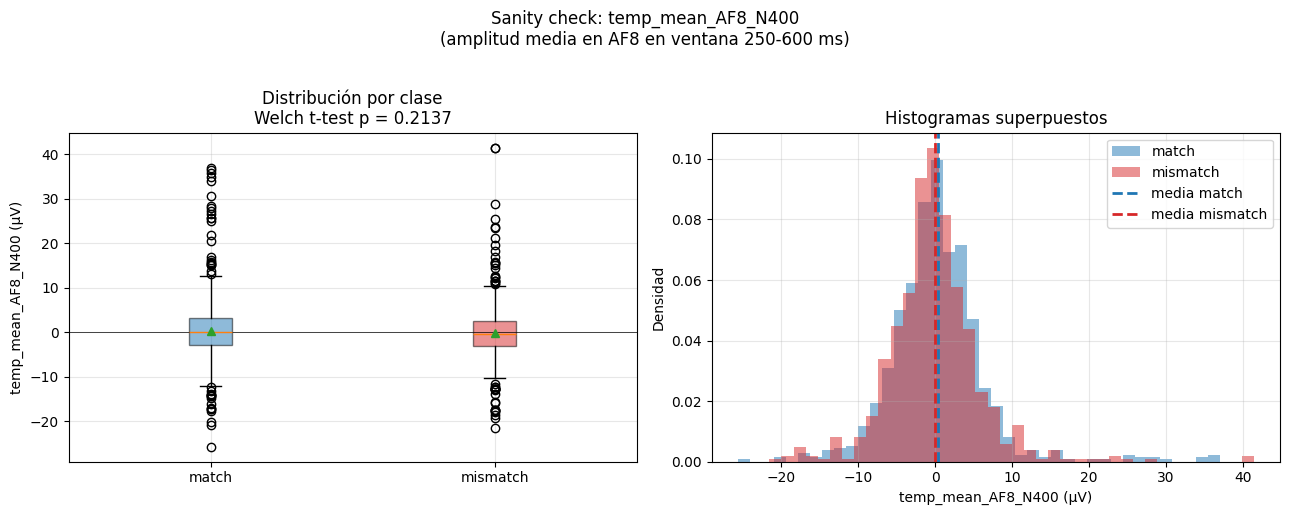

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
data_to_plot = [match_vals, mismatch_vals]
bp = axes[0].boxplot(data_to_plot, labels=['match', 'mismatch'], patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['tab:blue', 'tab:red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[0].set_ylabel(f'{key_feature} (µV)')
axes[0].set_title(f'Distribución por clase\nWelch t-test p = {t_pval:.4g}')
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='k', linewidth=0.5)

# Histogramas superpuestos
axes[1].hist(match_vals,    bins=40, alpha=0.5, color='tab:blue', label='match',    density=True)
axes[1].hist(mismatch_vals, bins=40, alpha=0.5, color='tab:red',  label='mismatch', density=True)
axes[1].axvline(np.mean(match_vals),    color='tab:blue', linestyle='--', linewidth=2, label=f'media match')
axes[1].axvline(np.mean(mismatch_vals), color='tab:red',  linestyle='--', linewidth=2, label=f'media mismatch')
axes[1].set_xlabel(f'{key_feature} (µV)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Histogramas superpuestos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'Sanity check: {key_feature}\n(amplitud media en AF8 en ventana 250-600 ms)', fontsize=12, y=1.02)
plt.tight_layout()

fig_path = FIGURES_DIR / '02_sanity_check_key_feature.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f'\n✓ Figura guardada: {fig_path}')
plt.show()

## 12. Análisis univariado de TODAS las features

Para cada feature, calculamos su poder discriminativo individual mediante el p-valor del Welch t-test entre clases. Las features con p más bajo serán las más informativas para el modelo (aunque correlaciones entre features pueden cambiar esto).

In [16]:
univariate_results = []
for col in feature_cols:
    a = df_features.loc[df_features['label'] == 0, col].values
    b = df_features.loc[df_features['label'] == 1, col].values
    # eliminar NaN/inf si los hubiera
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        continue
    t, p = stats.ttest_ind(a, b, equal_var=False)
    univariate_results.append({
        'feature': col,
        'mean_match':    float(np.mean(a)),
        'mean_mismatch': float(np.mean(b)),
        'difference':    float(np.mean(b) - np.mean(a)),
        'welch_t':       float(t),
        'p_value':       float(p),
    })

df_univ = pd.DataFrame(univariate_results).sort_values('p_value').reset_index(drop=True)

print(f'=== TOP 15 FEATURES POR DISCRIMINACIÓN INDIVIDUAL ===\n')
print(df_univ.head(15).to_string(index=False))

df_univ.to_csv(REPORTS_DIR / '02_univariate_feature_analysis.csv', index=False)
print(f'\n✓ Guardado: reports/02_univariate_feature_analysis.csv')

# Validación teórica: ¿las features del AF8 en N400 están entre las más discriminativas?
top10 = df_univ.head(10)
af8_n400 = top10[top10['feature'].str.contains('AF8_N400')]
print(f'\nFeatures AF8 + ventana N400 en top 10: {len(af8_n400)}')
if len(af8_n400) > 0:
    print('✓ Las features teóricamente relevantes están entre las más discriminativas — consistente con la literatura.')
    for _, row in af8_n400.iterrows():
        print(f"   • {row['feature']:40s} p = {row['p_value']:.4g}")

=== TOP 15 FEATURES POR DISCRIMINACIÓN INDIVIDUAL ===

                       feature    mean_match  mean_mismatch    difference   welch_t  p_value
             temp_std_AF7_full  8.732282e+00   9.418191e+00  6.859089e-01 -3.522223 0.000443
             temp_ptp_AF7_full  4.500580e+01   4.863853e+01  3.632733e+00 -3.482252 0.000514
             temp_ptp_AF7_N400  3.386158e+01   3.619463e+01  2.333053e+00 -3.328388 0.000899
             temp_var_AF7_full  8.809482e+01   1.041283e+02  1.603347e+01 -2.994665 0.002803
          cross_diff_beta_N400  4.950666e-12   1.126775e-11  6.317086e-12 -2.922472 0.003562
             temp_std_AF7_N400  7.956388e+00   8.462608e+00  5.062208e-01 -2.912556 0.003650
            freq_beta_AF7_N400  2.297571e-11   2.887825e-11  5.902540e-12 -2.722313 0.006609
             temp_var_AF7_N400  7.225501e+01   8.425942e+01  1.200440e+01 -2.555198 0.010745
          cross_diff_beta_full  6.548167e-12   1.105755e-11  4.509379e-12 -2.428517 0.015356
freq_ratio_beta

## 13. Correlación entre features

Visualizamos la estructura de correlaciones para detectar redundancias. Features extremadamente correlacionadas no aportan información independiente.

In [17]:
X_only = df_features[feature_cols].copy()
# Reemplazar inf por NaN, luego rellenar con 0 para correlación robusta
X_only = X_only.replace([np.inf, -np.inf], np.nan).fillna(0)

corr = X_only.corr()

# Pares con |corr| > 0.95 (excluyendo diagonal)
corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        c = corr.iloc[i, j]
        if abs(c) > 0.95:
            corr_pairs.append((corr.columns[i], corr.columns[j], c))

print(f'Pares de features con |correlación| > 0.95: {len(corr_pairs)}')
if corr_pairs:
    print('\nEjemplos (top 10 por |corr|):')
    for f1, f2, c in sorted(corr_pairs, key=lambda x: -abs(x[2]))[:10]:
        print(f'   {c:+.3f}  {f1}  ↔  {f2}')
    print('\nNota: estas redundancias las manejarán los modelos con regularización (L1/L2/L1+L2).')
    print('No se eliminan a priori para preservar interpretabilidad SHAP en Notebook 07.')

Pares de features con |correlación| > 0.95: 10

Ejemplos (top 10 por |corr|):
   +1.000  temp_mean_AF8_full  ↔  temp_auc_AF8_full
   +1.000  temp_mean_AF7_full  ↔  temp_auc_AF7_full
   +1.000  temp_mean_AF8_N400  ↔  temp_auc_AF8_N400
   +1.000  temp_mean_AF7_N400  ↔  temp_auc_AF7_N400
   +0.970  temp_std_AF7_full  ↔  temp_var_AF7_full
   +0.968  temp_std_AF8_full  ↔  temp_var_AF8_full
   +0.960  temp_std_AF7_full  ↔  temp_ptp_AF7_full
   +0.958  temp_std_AF8_N400  ↔  temp_ptp_AF8_N400
   +0.955  temp_std_AF8_full  ↔  temp_ptp_AF8_full
   +0.953  temp_std_AF8_N400  ↔  temp_var_AF8_N400

Nota: estas redundancias las manejarán los modelos con regularización (L1/L2/L1+L2).
No se eliminan a priori para preservar interpretabilidad SHAP en Notebook 07.


✓ Heatmap guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/02_top25_correlation_heatmap.png


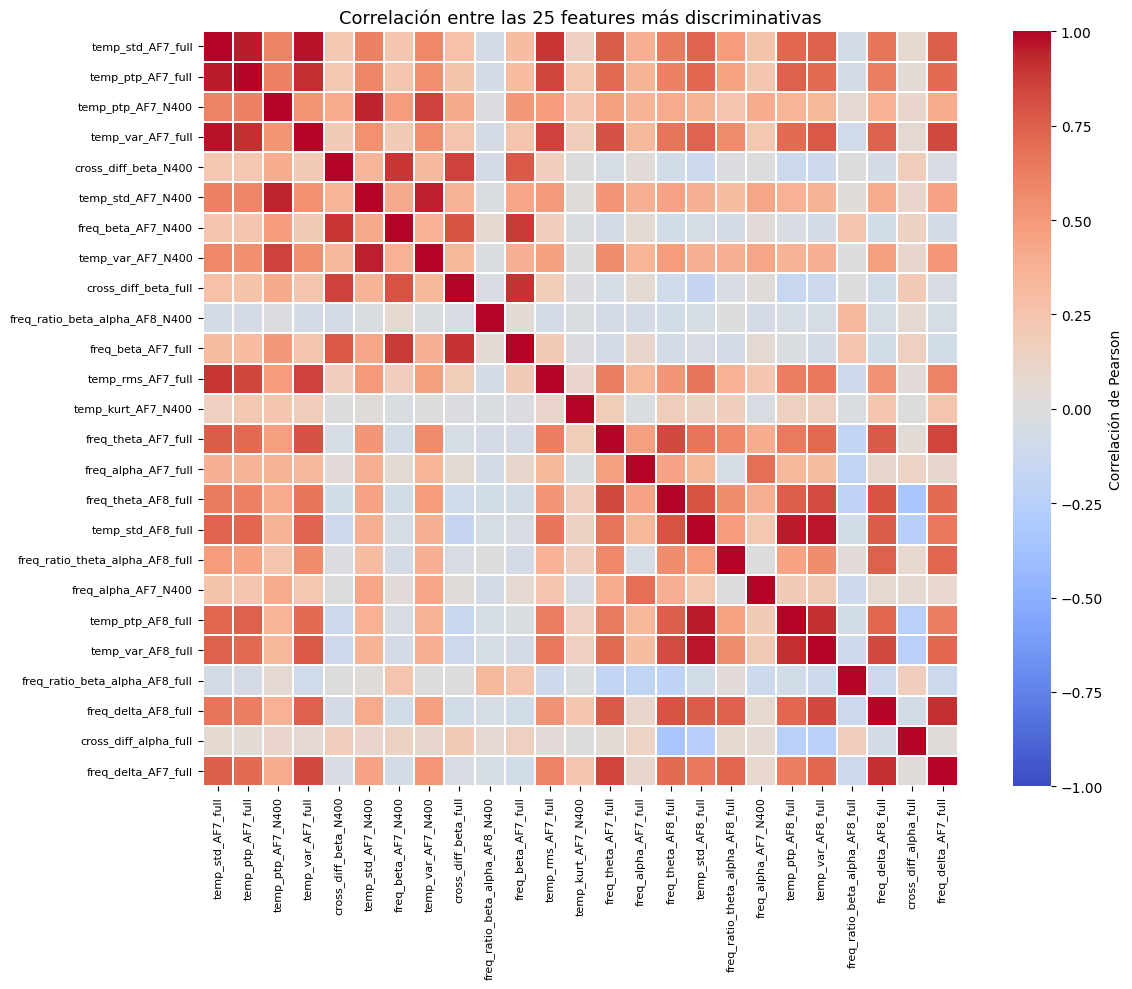

In [18]:
# Heatmap de las features más discriminativas (top 25)
top_feats = df_univ['feature'].head(25).tolist()
corr_top = X_only[top_feats].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_top, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Correlación de Pearson'},
            xticklabels=True, yticklabels=True, linewidths=0.3)
plt.title('Correlación entre las 25 features más discriminativas', fontsize=13)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
fig_path = FIGURES_DIR / '02_top25_correlation_heatmap.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f'✓ Heatmap guardado: {fig_path}')
plt.show()

## 14. Resumen final del Notebook 02

## Lo que hay que verificar antes de pasar al Notebook 03

1. **Total de features** debería rondar 50–60.
2. **El sanity check estadístico**: el p-valor del Welch t-test sobre `temp_mean_AF8_N400` debe ser **< 0.05** (idealmente < 0.001). Si es así, hay señal discriminativa real.
3. **Features AF8 + ventana N400 entre las top 10** del análisis univariado — confirma que la teoría está alineada con los datos.
4. **Sin valores `NaN` ni `inf`** en el CSV final.
